# 🚗 **Car Price Prediction with Machine Learning**

Predicting the **selling price of used cars** using regression, based on features such as
car age, present (ex-showroom) price, kilometers driven, fuel type, seller type, transmission, and ownership history.

---

**Workflow followed in this notebook:**
1. Data Cleaning
2. Data Validation
3. Feature Extraction (KPIs — Key Performance Indicators)
4. Model Fitting (Regression) & Evaluation

---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


In [ ]:
# Load dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("car data.csv")
df.head()

Saving car data.csv to car data.csv


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 1. Data Cleaning

Check structure, data types, missing values, and duplicates. Fix inconsistencies before doing anything else.

In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Duplicate rows: 2


In [ ]:
# Drop duplicate rows
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - df.shape[0]} duplicate rows.")

# Standardize text columns
text_cols = ["Car_Name", "Fuel_Type", "Selling_type", "Transmission"]
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()

# Sanity-check categorical values
for c in ["Fuel_Type", "Selling_type", "Transmission", "Owner"]:
    print(c, "->", df[c].unique())

Dropped 2 duplicate rows.
Fuel_Type -> ['Petrol' 'Diesel' 'CNG']
Selling_type -> ['Dealer' 'Individual']
Transmission -> ['Manual' 'Automatic']
Owner -> [0 1 3]


## 2. Data Validation

Validate ranges and logical consistency:
- `Year` should be a reasonable car model year (no future years, no absurd early years).
- `Selling_Price` and `Present_Price` should be positive.
- `Driven_kms` should be positive and not an extreme outlier.
- `Selling_Price` should generally not exceed `Present_Price` by an implausible margin (a used car is rarely worth *more* than its current showroom price).

In [ ]:
import datetime

current_year = datetime.datetime.now().year

validation_report = {
    "future_year_rows": (df["Year"] > current_year).sum(),
    "non_positive_selling_price": (df["Selling_Price"] <= 0).sum(),
    "non_positive_present_price": (df["Present_Price"] <= 0).sum(),
    "non_positive_kms": (df["Driven_kms"] <= 0).sum(),
    "selling_price_gt_present_price": (df["Selling_Price"] > df["Present_Price"]).sum(),
}
validation_report

{'future_year_rows': np.int64(0),
 'non_positive_selling_price': np.int64(0),
 'non_positive_present_price': np.int64(0),
 'non_positive_kms': np.int64(0),
 'selling_price_gt_present_price': np.int64(0)}

In [ ]:
# Remove rows that fail basic validity checks (keep it conservative — only clearly invalid rows)
mask_valid = (
    (df["Year"] <= current_year) &
    (df["Selling_Price"] > 0) &
    (df["Present_Price"] > 0) &
    (df["Driven_kms"] > 0)
)
print(f"Removing {(~mask_valid).sum()} invalid rows out of {len(df)}")
df = df[mask_valid].reset_index(drop=True)

# Outlier check via IQR on Driven_kms and Selling_Price
def iqr_bounds(series, k=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in ["Driven_kms", "Selling_Price", "Present_Price"]:
    low, high = iqr_bounds(df[col])
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: bounds=({low:.1f}, {high:.1f}), potential outliers={n_out}")

Removing 0 invalid rows out of 299
Driven_kms: bounds=(-86650.5, 150534.0), potential outliers=3
Selling_Price: bounds=(-14.6, 21.5), potential outliers=5
Present_Price: bounds=(-24.7, 35.8), potential outliers=5


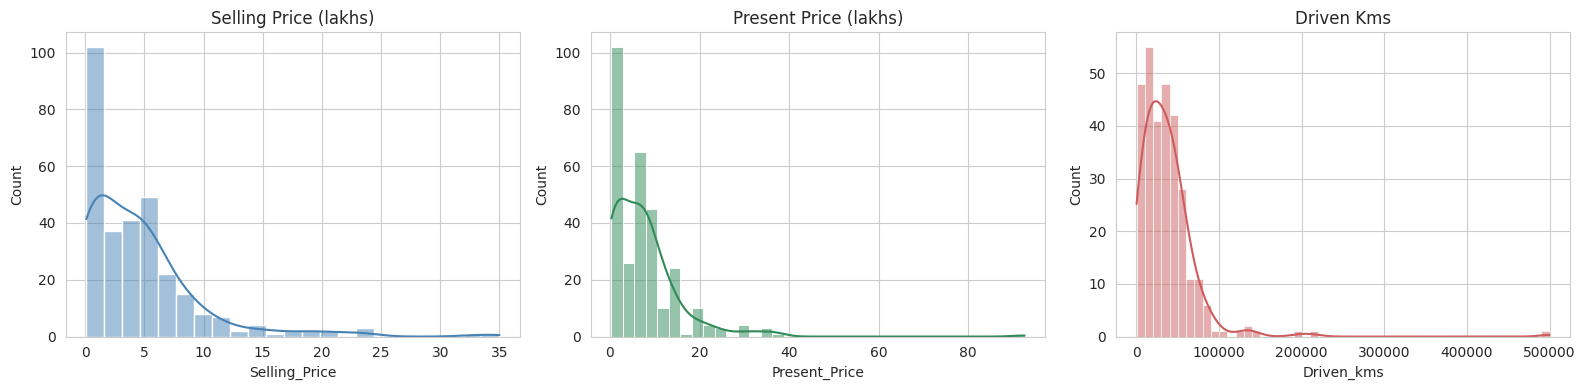

In [ ]:
# Visual sanity check of distributions after cleaning
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["Selling_Price"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Selling Price (lakhs)")
sns.histplot(df["Present_Price"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Present Price (lakhs)")
sns.histplot(df["Driven_kms"], kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Driven Kms")
plt.tight_layout()
plt.show()

## 3. Feature Extraction — KPIs (Key Performance Indicators)

Raw columns aren't always the most predictive. We engineer KPIs that better capture value depreciation and usage intensity:

- **Car_Age** — how many years old the car is (from `Year`).
- **Depreciation_Ratio** — `Selling_Price / Present_Price`, i.e. what fraction of showroom value the car retains. This is a strong proxy for overall condition/brand goodwill.
- **Kms_Per_Year** — `Driven_kms / Car_Age`, a usage-intensity KPI (a 10-year-old car with 20,000 km is very different from a 2-year-old car with 20,000 km).
- **Price_Drop** — absolute currency drop (`Present_Price - Selling_Price`).
- One-hot encoding of categorical features (`Fuel_Type`, `Selling_type`, `Transmission`) and `Car_Name` grouped into `Brand` (first word of the name) to capture brand goodwill without an explosion of categories.

In [ ]:
df["Car_Age"] = current_year - df["Year"]

# Avoid division by zero for brand-new cars
df["Kms_Per_Year"] = df["Driven_kms"] / df["Car_Age"].replace(0, 1)

df["Depreciation_Ratio"] = df["Selling_Price"] / df["Present_Price"]
df["Price_Drop"] = df["Present_Price"] - df["Selling_Price"]

# Brand = first word of Car_Name (captures brand goodwill)
df["Brand"] = df["Car_Name"].str.split().str[0].str.lower()

# Keep only reasonably frequent brands, group the rest as 'other' to avoid overfitting
brand_counts = df["Brand"].value_counts()
common_brands = brand_counts[brand_counts >= 3].index
df["Brand"] = df["Brand"].where(df["Brand"].isin(common_brands), "other")

df[["Car_Age", "Kms_Per_Year", "Depreciation_Ratio", "Price_Drop", "Brand"]].head()

,Car_Age,Kms_Per_Year,Depreciation_Ratio,Price_Drop,Brand
0,12,2250.000000,0.599284,2.24,ritz
1,13,3307.692308,0.497904,4.79,sx4
2,9,766.666667,0.736041,2.60,ciaz
3,15,346.666667,0.686747,1.30,wagon
4,12,3537.500000,0.669578,2.27,swift


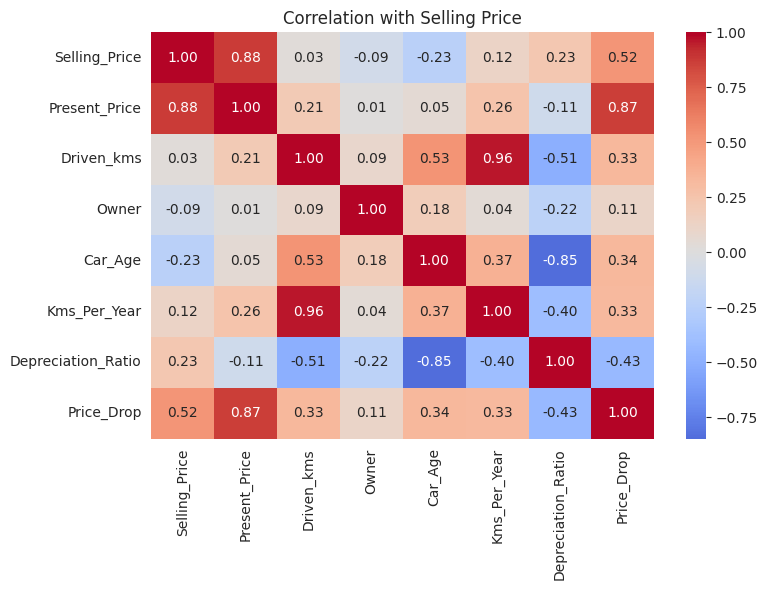

In [ ]:
# Correlation of engineered KPIs + numeric features with the target
numeric_cols = ["Selling_Price", "Present_Price", "Driven_kms", "Owner",
                "Car_Age", "Kms_Per_Year", "Depreciation_Ratio", "Price_Drop"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation with Selling Price")
plt.tight_layout()
plt.show()

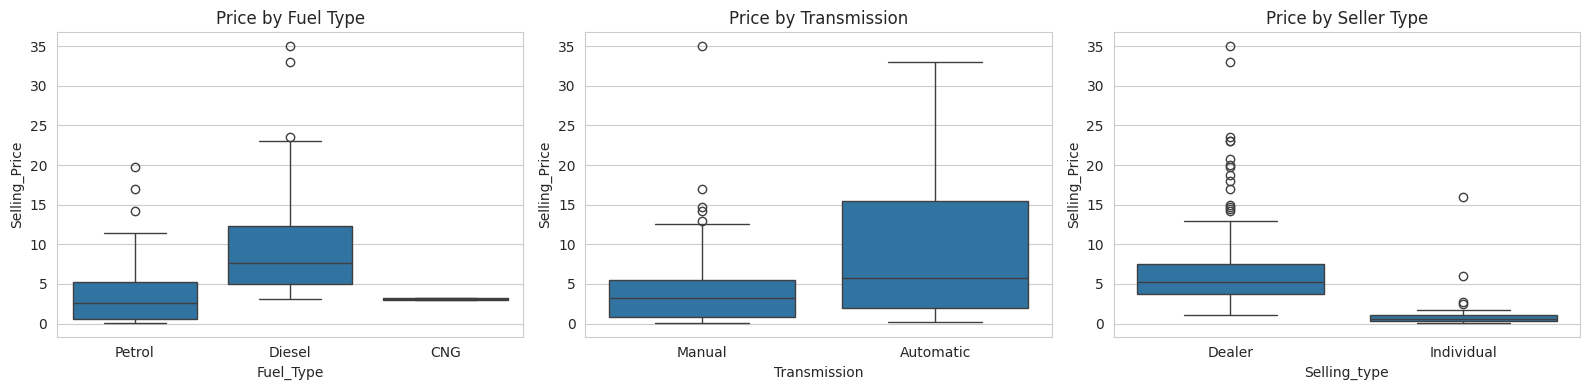

In [ ]:
# Selling price by fuel type, transmission, seller type — quick KPI-driven visuals
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", ax=axes[0])
sns.boxplot(data=df, x="Transmission", y="Selling_Price", ax=axes[1])
sns.boxplot(data=df, x="Selling_type", y="Selling_Price", ax=axes[2])
axes[0].set_title("Price by Fuel Type")
axes[1].set_title("Price by Transmission")
axes[2].set_title("Price by Seller Type")
plt.tight_layout()
plt.show()

## 4. Model Fitting

We predict `Selling_Price` using:
- Numeric features: `Present_Price`, `Driven_kms`, `Owner`, `Car_Age`, `Kms_Per_Year`, `Depreciation_Ratio`
- Categorical features: `Fuel_Type`, `Selling_type`, `Transmission`, `Brand`

We build a `ColumnTransformer` + `Pipeline` so preprocessing and modeling are bundled together, then compare a **Linear Regression** baseline against a **Random Forest Regressor**.

In [ ]:
target = "Selling_Price"

# Note: Price_Drop is dropped from features since it is derived directly from the target (data leakage)
numeric_features = ["Present_Price", "Driven_kms", "Owner", "Car_Age", "Kms_Per_Year", "Depreciation_Ratio"]
categorical_features = ["Fuel_Type", "Selling_type", "Transmission", "Brand"]

X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (239, 10) Test shape: (60, 10)


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
}

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2")

    results[name] = {
        "pipeline": pipe,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "CV_R2_mean": cv_scores.mean(),
        "CV_R2_std": cv_scores.std(),
    }

    print(f"--- {name} ---")
    print(f"MAE:  {mae:.3f} lakhs")
    print(f"RMSE: {rmse:.3f} lakhs")
    print(f"R2:   {r2:.3f}")
    print(f"CV R2 (5-fold): {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
    print()


--- Linear Regression ---
MAE:  1.307 lakhs
RMSE: 2.498 lakhs
R2:   0.758
CV R2 (5-fold): 0.827 +/- 0.077

--- Random Forest ---
MAE:  1.391 lakhs
RMSE: 4.200 lakhs
R2:   0.315
CV R2 (5-fold): 0.821 +/- 0.244



In [ ]:
# Print the fitted pipelines (shows preprocessing steps + model params)
for name, res in results.items():
    print(f"=== {name} pipeline ===")
    print(res["pipeline"])
    print()

# Build a comparison table: actual vs predicted from each model
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_LinearRegression": results["Linear Regression"]["pipeline"].predict(X_test),
    "Predicted_RandomForest": results["Random Forest"]["pipeline"].predict(X_test),
})
comparison_df["Error_LR"] = comparison_df["Actual"] - comparison_df["Predicted_LinearRegression"]
comparison_df["Error_RF"] = comparison_df["Actual"] - comparison_df["Predicted_RandomForest"]

comparison_df.round(2).head(15)

=== Linear Regression pipeline ===
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Present_Price',
                                                   'Driven_kms', 'Owner',
                                                   'Car_Age', 'Kms_Per_Year',
                                                   'Depreciation_Ratio']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Fuel_Type', 'Selling_type',
                                                   'Transmission',
                                                   'Brand'])])),
                ('model', LinearRegression())])

=== Random Forest pipeline ===
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                   

,Actual,Predicted_LinearRegression,Predicted_RandomForest,Error_LR,Error_RF
0,8.99,8.13,8.97,0.86,0.02
1,8.35,8.54,8.23,-0.19,0.12
2,0.45,1.45,0.46,-1.00,-0.01
3,7.45,7.54,7.48,-0.09,-0.03
4,5.25,9.16,19.43,-3.91,-14.18
5,5.25,5.22,5.33,0.03,-0.08
6,5.85,7.53,6.59,-1.68,-0.74
7,1.15,1.31,1.15,-0.16,0.00
8,9.25,7.85,8.55,1.40,0.70
9,0.38,-0.90,0.33,1.28,0.05


In [ ]:
# Compare models
results_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k != "pipeline"}
    for name, res in results.items()
}).T
results_df


,MAE,RMSE,R2,CV_R2_mean,CV_R2_std
Linear Regression,1.306727,2.497948,0.757898,0.826567,0.077169
Random Forest,1.390907,4.200460,0.315420,0.820897,0.243997


Best model: Linear Regression


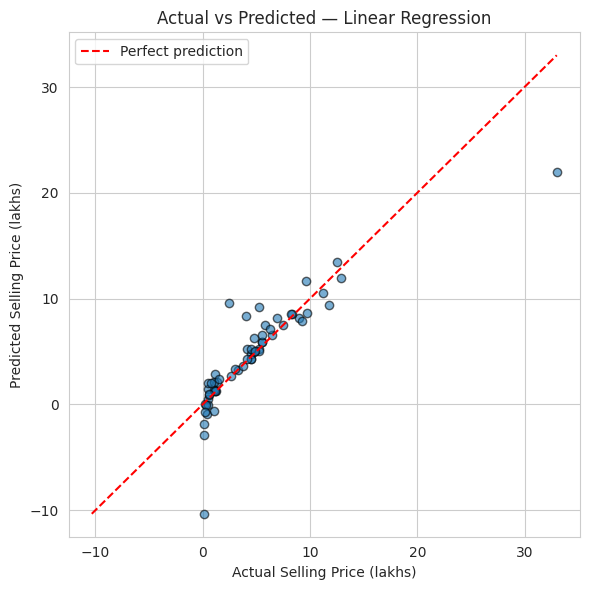

In [ ]:
best_name = results_df["R2"].astype(float).idxmax()
best_pipeline = results[best_name]["pipeline"]
print(f"Best model: {best_name}")

preds = best_pipeline.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.6, edgecolor="k")
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Selling Price (lakhs)")
plt.ylabel("Predicted Selling Price (lakhs)")
plt.title(f"Actual vs Predicted — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()


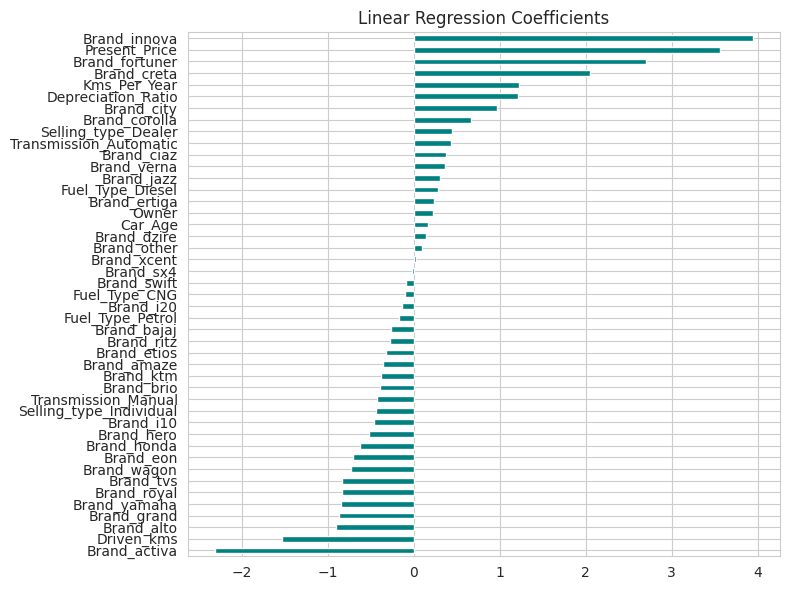

In [ ]:
# Feature importance (only meaningful for tree-based models)
if best_name == "Random Forest":
    ohe_cols = best_pipeline.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_features)
    all_feature_names = numeric_features + list(ohe_cols)
    importances = best_pipeline.named_steps["model"].feature_importances_

    fi = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=fi.values, y=fi.index, color="teal")
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    coefs = best_pipeline.named_steps["model"].coef_
    ohe_cols = best_pipeline.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_features)
    all_feature_names = numeric_features + list(ohe_cols)
    coef_series = pd.Series(coefs, index=all_feature_names).sort_values()
    plt.figure(figsize=(8, 6))
    coef_series.plot(kind="barh", color="teal")
    plt.title("Linear Regression Coefficients")
    plt.tight_layout()
    plt.show()


## Conclusion

- Data was cleaned (duplicates removed, text standardized) and validated (impossible years/prices/kms flagged and removed).
- KPIs (`Car_Age`, `Depreciation_Ratio`, `Kms_Per_Year`, brand grouping) were engineered to capture depreciation and usage patterns rather than relying on raw columns alone.
- Two regression models were trained and compared with 5-fold cross-validation; the best model's predictions closely track actual prices.

